# Modul 4


## Context & Objetive:
* Context: Create a tool for the sales team to send push notifications and thus encourage the purchase of specific products
* Objetivo: Develop a model that predicts whether a user would buy a particular product at a given time. Now loking also **non-lineal** models

In [1]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from typing import Tuple

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, precision_recall_curve, roc_curve, auc, precision_recall_fscore_support 
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

plt.style.use("fast")

## Read the DataSet

In [2]:
df = pd.read_csv('../data/sampled_box_builder_df.csv')

In [4]:
df.describe()

,variant_id,order_id,user_id,user_order_seq,outcome,ordered_before,abandoned_before,active_snoozed,set_as_regular,normalised_price,...,count_children,count_babies,count_pets,people_ex_baby,days_since_purchase_variant_id,avg_days_to_buy_variant_id,std_days_to_buy_variant_id,days_since_purchase_product_type,avg_days_to_buy_product_type,std_days_to_buy_product_type
count,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,...,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06,2.880549e+06
mean,3.401250e+13,2.978388e+12,3.750025e+12,3.289342e+00,1.153669e-02,2.113868e-02,6.092589e-04,2.290188e-03,3.629864e-03,1.272808e-01,...,5.492182e-02,3.538562e-03,5.134091e-02,2.072549e+00,3.312961e+01,3.523734e+01,2.645304e+01,3.143513e+01,3.088810e+01,2.594969e+01
std,2.786246e+11,2.446292e+11,1.775710e+11,2.140176e+00,1.067876e-01,1.438466e-01,2.467565e-02,4.780109e-02,6.013891e-02,1.268378e-01,...,3.276586e-01,5.938048e-02,3.013646e-01,3.943659e-01,3.707162e+00,1.057766e+01,7.168323e+00,1.227511e+01,4.330262e+00,3.278860e+00
min,3.361529e+13,2.807986e+12,3.046041e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.599349e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.414214e+00,0.000000e+00,7.000000e+00,2.828427e+00
25%,3.380354e+13,2.875152e+12,3.745901e+12,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.394416e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.000000e+01,2.319372e+01,3.000000e+01,2.800000e+01,2.427618e+01
50%,3.397325e+13,2.902856e+12,3.812775e+12,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.105178e-02,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,3.400000e+01,2.769305e+01,3.000000e+01,3.100000e+01,2.608188e+01
75%,3.428495e+13,2.922034e+12,3.874925e+12,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.352670e-01,...,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,3.300000e+01,4.000000e+01,3.059484e+01,3.000000e+01,3.400000e+01,2.796118e+01
max,3.454300e+13,3.643302e+12,5.029635e+12,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,3.000000e+00,1.000000e+00,6.000000e+00,5.000000e+00,1.480000e+02,8.400000e+01,5.868986e+01,1.480000e+02,3.950000e+01,3.564191e+01


In [3]:
info_cols = ["variant_id", "order_id", "user_id", "created_at", "order_date"]
label_col = "outcome"
features_cols = [col for col in df.columns if col not in info_cols + [label_col]]

categorical_cols = ["product_type", "vendor"]
binary_cols = ["ordered_before", "abandoned_before", "active_snoozed", "set_as_regular"]
numerical_cols = [col for col in features_cols if col not in categorical_cols + binary_cols]

### We filter the data
We only need the orders with minimum 5 articles relly buy it.


In [4]:
def push_relevant_dataframe(df: pd.DataFrame, min_products: int=5) -> pd.DataFrame:
    # Calculamos cuántos productos se compraron REALMENTE en cada pedido (sumando los 1s de outcome)
    df['real_purchase_size'] = df.groupby('order_id')['outcome'].transform('sum')

    # Filtramos por pedidos donde se compraron 5 o más cosas
    return df[df['real_purchase_size'] >= min_products].copy()

def format_data_columns(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df
        .assign(created_at=lambda x: pd.to_datetime(x.created_at))
        .assign(order_date=lambda x: pd.to_datetime(x.order_date).dt.date)
    )
df_selected = (
    df
    .pipe(push_relevant_dataframe)
    .pipe(format_data_columns)
)

## Data Split

In [5]:
daily_orders = df_selected.groupby("order_date").order_id.nunique()

Text(0.5, 1.0, 'Daily Orders')

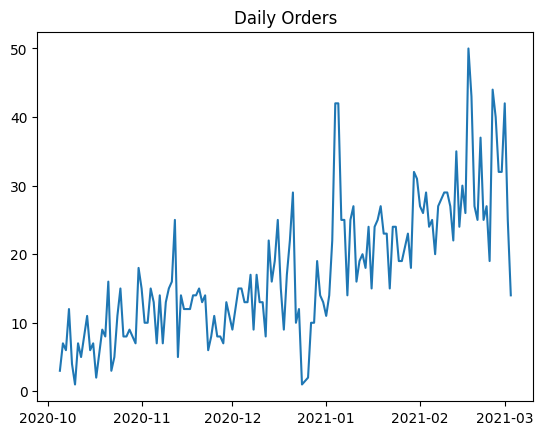

In [8]:
plt.plot(daily_orders, label="daily orders")
plt.title("Daily Orders")

We can see that the business has grow temporaly. We must not ignored that the dynamics has been change during the pass of time, so to don't fall in information leakage is important to work only we information in the past. The business change, apears new products, new trends,...
Makes senses to do a temporal split. (we don't split the same rders in train and validation neather)

In [6]:
cumsum_daily_orders = daily_orders.cumsum() / daily_orders.sum()

train_val_cutoff = cumsum_daily_orders[cumsum_daily_orders <= 0.7].idxmax()
val_test_cutoff = cumsum_daily_orders[cumsum_daily_orders <= 0.9].idxmax()

In [7]:
train_df = df_selected[df_selected.order_date <= train_val_cutoff]
val_df = df_selected[
    (df_selected.order_date > train_val_cutoff) 
    & (df_selected.order_date <= val_test_cutoff)
]
test_df = df_selected[df_selected.order_date > val_test_cutoff]

In [8]:
def feature_label_split(
    df: pd.DataFrame, label_col: str 
) -> Tuple[pd.DataFrame, pd.Series]:
    return df.drop(label_col, axis=1), df[label_col]

X_train, y_train = feature_label_split(train_df, label_col)
X_val, y_val = feature_label_split(val_df, label_col)
X_test, y_test = feature_label_split(test_df, label_col)

## Baseline
* We creat the metrics we area going to use to compare models
* We also define our baseline

In [9]:
def evaluation_model(clf, X_train, y_train, X_val, y_val, model_name="Modelo"):
    
    train_probs = clf.predict_proba(X_train)[:, 1]
    val_probs = clf.predict_proba(X_val)[:, 1]
    
    metrics = {
        "model": model_name,
        # ROC AUC
        "train_roc_auc": round(roc_auc_score(y_train, train_probs), 4),
        "val_roc_auc": round(roc_auc_score(y_val, val_probs), 4),
        
        # Average Precision: Area under the PR curve
        "train_ap": round(average_precision_score(y_train, train_probs), 4),
        "val_ap": round(average_precision_score(y_val, val_probs), 4),
        
        # Log Loss / Cross-Entropy: Penalice the error
        "train_logloss": round(log_loss(y_train, train_probs), 4),
        "val_logloss": round(log_loss(y_val, val_probs), 4)
    }
    
    return metrics

Previously we had use the "global_popularity" column as a baseline. However to save time we are going to us has baselen the lineal models we finde better in the previous module. Ridge with c=1e-06

In [10]:
train_cols = numerical_cols + binary_cols

In [ ]:
resultados = []

cs = [1e-6, 1e-4, 1e-2, 1, 100, None]
for c in cs:
    lr = make_pipeline(
        StandardScaler(), # normalizo los datos con media 0 y var 1
        LogisticRegression(
            penalty="l2", # Indica que tiene regularizacion tipo Ridge
            C=c if c else 1.0, 
            max_iter=1000
        )
    )

    lr.fit(X_train[train_cols], y_train)

    m = evaluation_model(lr, X_train[train_cols], y_train, X_val[train_cols], y_val, model_name=f"Ridge_c={c}")
    resultados.append(m)

df_results = pd.DataFrame(resultados)
display(df_results)  


In [ ]:
resultados = []
reduced_cols = ["ordered_before","abandoned_before", "global_popularity"]
columns = [train_cols, reduced_cols]
for cols in columns:
    lr = make_pipeline(
            StandardScaler(), # normalizo los datos con media 0 y var 1
            LogisticRegression(
                penalty="l2", # Indica que tiene regularizacion tipo Ridge
                C=1e-06, 
                max_iter=1000
            )
        )
    lr.fit(X_train[cols], y_train)

    m = evaluation_model(lr, X_train[cols], y_train, X_val[cols], y_val, model_name=f"Ridge_c")
    resultados.append(m)

In [ ]:
display(resultados)

[{'model': 'Ridge_c',
  'train_roc_auc': 0.8254,
  'val_roc_auc': 0.8326,
  'train_ap': 0.1562,
  'val_ap': 0.1603,
  'train_logloss': 0.0762,
  'val_logloss': 0.0694},
 {'model': 'Ridge_c',
  'train_roc_auc': 0.833,
  'val_roc_auc': 0.8344,
  'train_ap': 0.1625,
  'val_ap': 0.1484,
  'train_logloss': 0.0764,
  'val_logloss': 0.0702}]

We are going to use as Baseline: Ridge c=1e-06, with the reduced_cols

## Model Training
We are going to study the non-lineal models just to know if we improve the lineal model baseline.
## Non-Lineal Models

## Random Forest

In [ ]:
n_trees_grid = [5, 25, 50, 100]

# 2. Preparamos las listas para guardar métricas (estilo ejemplo del profe)
rf_train_aucs, rf_val_aucs = [], []
rf_train_ce, rf_val_ce = [], []
rf_train_aps, rf_val_aps = [], []

# Usamos las columnas que definimos antes (numéricas + binarias)
# columns = numerical_cols + binary_cols
columns = ["ordered_before","abandoned_before", "global_popularity"]
for n_trees in n_trees_grid:
    # Creamos el modelo
    # random_state es clave para que los resultados sean siempre los mismos
    rf = RandomForestClassifier(n_estimators=n_trees, random_state=42, n_jobs=-1)
    
    # Entrenamos
    rf.fit(X_train[columns], y_train)
    
    # Evaluamos (Usando tu función de evaluación que devuelve el diccionario)
    # Importante: aquí pasamos las listas para ir añadiendo los resultados
    m = evaluation_model(
        rf, 
        X_train[columns], y_train, 
        X_val[columns], y_val, 
        model_name=f"RF_{n_trees}_trees"
    )
    
    # Guardamos en las listas (para que el print funcione como el del profe)
    rf_train_aucs.append(m['train_roc_auc'])
    rf_val_aucs.append(m['val_roc_auc'])
    rf_train_ce.append(m['train_logloss'])
    rf_val_ce.append(m['val_logloss'])
    rf_train_aps.append(m['train_ap'])
    rf_val_aps.append(m['val_ap'])
    
    # Print de seguimiento idéntico al ejemplo
    print(f"# Trees: {n_trees} done with train auc: {rf_train_aucs[-1]:.4f} and val auc: {rf_val_aucs[-1]:.4f}")
    print(f"AP train: {rf_train_aps[-1]:.4f} and val: {rf_val_aps[-1]:.4f}")
    print(f"Cross entropy train: {rf_train_ce[-1]:.4f}, val: {rf_val_ce[-1]:.4f}\n")

# Para que luego puedas graficarlo igual que la regresión logística:
# resultados.append(m) ... si quieres meterlos en el DataFrame comparativo

# Trees: 5 done with train auc: 0.8567 and val auc: 0.7013
AP train: 0.2417 and val: 0.1081
Cross entropy train: 0.0596, val: 0.1350

# Trees: 25 done with train auc: 0.8595 and val auc: 0.7133
AP train: 0.2501 and val: 0.1120
Cross entropy train: 0.0588, val: 0.1267

# Trees: 50 done with train auc: 0.8598 and val auc: 0.7167
AP train: 0.2512 and val: 0.1121
Cross entropy train: 0.0588, val: 0.1233

# Trees: 100 done with train auc: 0.8599 and val auc: 0.7177
AP train: 0.2518 and val: 0.1117
Cross entropy train: 0.0587, val: 0.1212



* I had to limit the columns because my computer wouldn't load
* We don't observe any improve from he lineal model
* Usually if we incrise the number off trees we should improve our model. We can see that in the AUC of validation for exemple.
* Lets see one time if 100 trees and using all the non-categorical columns work better

In [ ]:
columns = numerical_cols + binary_cols
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=10, random_state=42)
rf.fit(X_train[columns], y_train)
m = evaluation_model(
        rf, 
        X_train[columns], y_train, 
        X_val[columns], y_val, 
        model_name=f"RF_100_trees"
    )
display(m)

{'model': 'RF_100_trees',
 'train_roc_auc': 0.8465,
 'val_roc_auc': 0.8425,
 'train_ap': 0.2425,
 'val_ap': 0.2015,
 'train_logloss': 0.0612,
 'val_logloss': 0.0564}

We can apreciet that we had improve the average recision but we had little less of validation logloss.


## Gradient boosting trees

In [ ]:
results=[]
n_trees_grid = [5, 25, 50]

gbt_train_aucs, gbt_val_aucs = [], []
gbt_train_ce, gbt_val_ce = [], []
gbt_train_aps, gbt_val_aps = [], []

# columns = numerical_cols + binary_cols
columns = ["ordered_before","abandoned_before", "global_popularity", "set_as_regular", "active_snoozed", "normalised_price"]
for lr in [0.05, 0.1]:
    for depth in [1, 3, 5]: # from 5 to  onwards is already too much
        for n_trees in n_trees_grid:
            gbt = GradientBoostingClassifier(learning_rate=lr, max_depth= depth, n_estimators=n_trees, random_state=42)
            gbt.fit(X_train[columns], y_train)
    
    # Evaluamos (Usando tu función de evaluación que devuelve el diccionario)
    # Importante: aquí pasamos las listas para ir añadiendo los resultados
            m = evaluation_model(
                    gbt, 
                    X_train[columns], y_train, 
                    X_val[columns], y_val, 
                    model_name=f"GBT_{n_trees}_trees_depth_{depth}_lr_{lr}"
                )
            results.append(m)

df_results = pd.DataFrame(results)
display(df_results)  

,model,train_roc_auc,val_roc_auc,train_ap,val_ap,train_logloss,val_logloss
0,GBT_5_trees_depth_1_lr_0.05,0.6461,0.6543,0.0909,0.0763,0.0729,0.0670
1,GBT_25_trees_depth_1_lr_0.05,0.7680,0.7544,0.1332,0.1214,0.0691,0.0635
2,GBT_50_trees_depth_1_lr_0.05,0.8163,0.8109,0.1554,0.1418,0.0662,0.0609
3,GBT_5_trees_depth_3_lr_0.05,0.7793,0.7677,0.1524,0.1388,0.0701,0.0647
4,GBT_25_trees_depth_3_lr_0.05,0.8221,0.8232,0.1751,0.1654,0.0651,0.0594
5,GBT_50_trees_depth_3_lr_0.05,0.8361,0.8409,0.1833,0.1777,0.0632,0.0572
6,GBT_5_trees_depth_5_lr_0.05,0.8335,0.8376,0.1751,0.1647,0.0693,0.0635
7,GBT_25_trees_depth_5_lr_0.05,0.8371,0.8414,0.1874,0.1763,0.0637,0.0578
8,GBT_50_trees_depth_5_lr_0.05,0.8381,0.8422,0.1928,0.1795,0.0624,0.0565
9,GBT_5_trees_depth_1_lr_0.1,0.6461,0.6543,0.0909,0.0763,0.0709,0.0652


* We also can see that if we increase the number of trees the model is better
* Also that in general the learning rate looks work better if its higher.
* The best option we find is 50 trees, debth of 5 and lr of 0.1.

## Other models?

In class we saw that there aren't better models to aplied in this business case

## Comper models 
Graficar las 4 mejores versiones en la curba de Precision-Recall por ejemplo y ROC

How we compare?
What we have to priorice and what is most costly for the compane and haow to reduced? we prefer to miss potential users (lower recall = we send less notification but are more sure) or to bother an user and loss their confidence with us (lower precision = more notification but easier to miss). 
This are question we must answer during our studie.

In [10]:
def plot_metrics(
        model_name,
        y_pred,
        y_test,
        target_precision: float = 0.05,
        figure: Tuple[matplotlib.figure.Figure, np.array] = None,
):
    precision_, recall_, _ = precision_recall_curve(y_test, y_pred) 
    pr_auc = auc(recall_, precision_) 

    fpr, tpr, _ = roc_curve(y_test, y_pred) 
    roc_auc = roc_auc_score(y_test, y_pred)

    if figure is None:
        fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    else:
        fig, ax = figure

    ax[0].plot(recall_, precision_, label=f"{model_name}: AUC: {pr_auc:.2f}")
    ax[0].set_xlabel("recall")
    ax[0].set_ylabel("precision")
    ax[0].set_title(f"Precision-recall Curve")
    ax[0].legend()

    ax[1].plot(fpr, tpr, label=f"AUC: {roc_auc:.2f}")
    ax[1].set_xlabel("FPR")
    ax[1].set_ylabel("TPR")
    ax[1].set_title(f"ROC Curve")
    ax[1].legend()


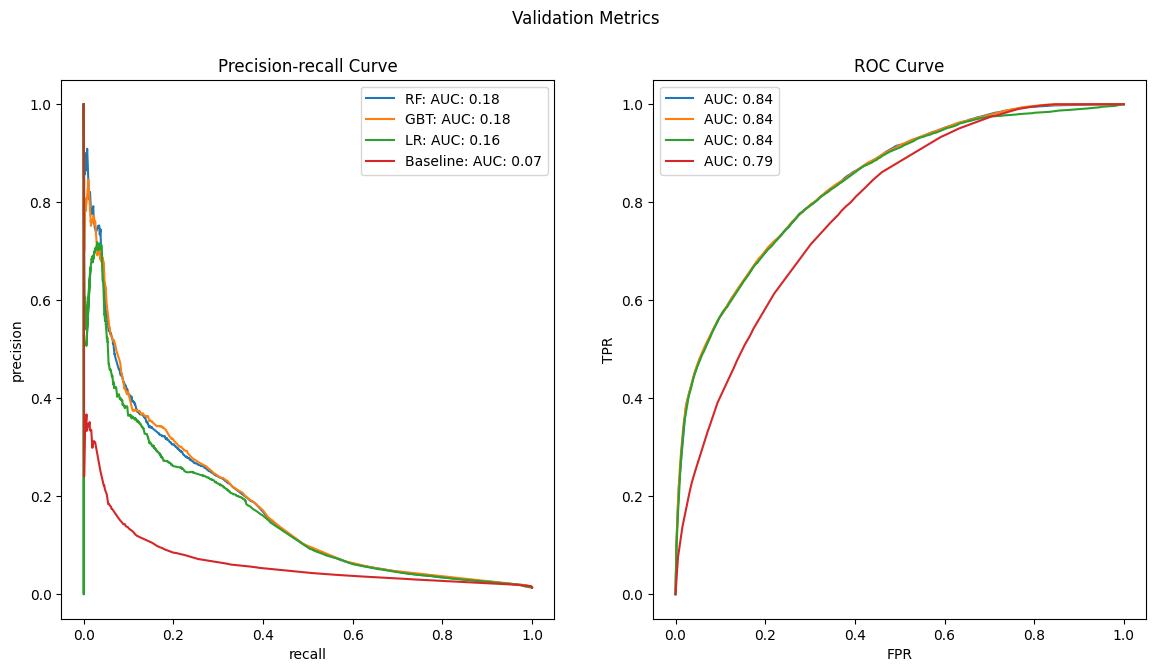

In [11]:
fig1, ax1 = plt.subplots(1, 2, figsize=(14, 7))
fig1.suptitle("Validation Metrics")

train_cols = ["ordered_before","abandoned_before", "global_popularity", "set_as_regular", "active_snoozed", "normalised_price"]

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=10, random_state=42)
rf.fit(X_train[train_cols], y_train)
val_proba = rf.predict_proba(X_val[train_cols])[:, 1]
plot_metrics(
    f"RF", y_pred=val_proba, y_test=val_df[label_col], figure=(fig1, ax1)
)

gbt = GradientBoostingClassifier(learning_rate=0.1, max_depth= 5, n_estimators=50, random_state=42)
gbt.fit(X_train[train_cols], y_train)
val_proba = gbt.predict_proba(X_val[train_cols])[:, 1]
plot_metrics(
    f"GBT", y_pred=val_proba, y_test=val_df[label_col], figure=(fig1, ax1)
)

lr = make_pipeline(
        StandardScaler(), # normalizo los datos con media 0 y var 1
        LogisticRegression(
            penalty="l2", # Indica que tiene regularizacion tipo Ridge
            C=1e-06, 
            max_iter=1000
        )
    )
lr.fit(X_train[train_cols], y_train)
val_proba = lr.predict_proba(X_val[train_cols])[:, 1]
plot_metrics(
        f"LR", y_pred=val_proba, y_test=val_df[label_col], figure=(fig1, ax1)
    )

plot_metrics(
    f"Baseline", 
    y_pred=val_df["global_popularity"], 
    y_test=val_df[label_col], 
    figure=(fig1, ax1)
)

The best options has been the GBT. So from now on we are going to work only with that

## Calibratio

Dibujamos la curva de calibracion pra la reggresion logistica y para el GBT 
Luego aplicamos el isotonicRegression para mejorarlo con los datos de validacion y volvemos a comparar

First let see the actual calibration level of our best models, de logistic regression and the Gradient Boosting Tree

In [18]:
lr = make_pipeline(
        StandardScaler(), # normalizo los datos con media 0 y var 1
        LogisticRegression(
            penalty="l2", # Indica que tiene regularizacion tipo Ridge
            C=1e-06
        )
    )
lr.fit(X_train[train_cols], y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1e-06))])

In [12]:
lr_predictions = lr.predict_proba(X_val[train_cols])[:, 1]
gbt_predictions = gbt.predict_proba(X_val[train_cols])[:, 1]

In [13]:
lr_prob_true, lr_prob_pred = calibration_curve(y_val, lr_predictions, n_bins=20)
gbt_prob_true, gbt_prob_pred = calibration_curve(y_val, gbt_predictions, n_bins=20)

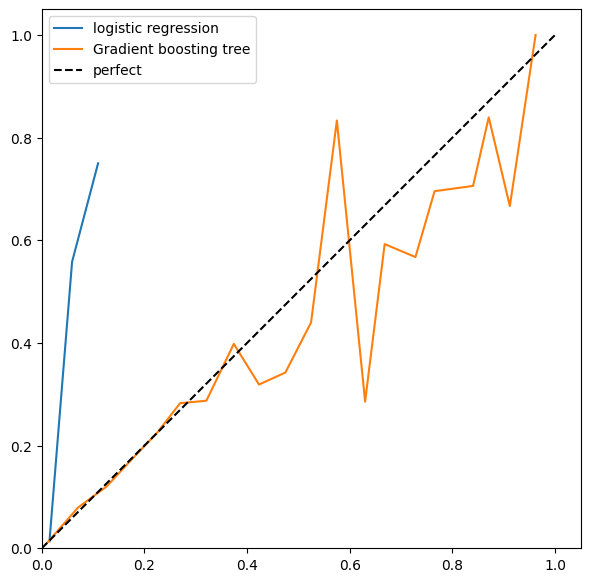

In [14]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot(lr_prob_pred, lr_prob_true, label="logistic regression")
ax.plot(gbt_prob_pred, gbt_prob_true, label="Gradient boosting tree")
ax.plot([0, 1],[0, 1], color="k", linestyle="--", label="perfect")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1.05)
ax.set_aspect("equal", "box")
ax.legend()

GBT is much better calibrated.

Lets try to calibret more the model to more acurrate.

In [15]:
calibrated_lr = CalibratedClassifierCV(lr, cv="prefit", method="isotonic")
calibrated_gbt = CalibratedClassifierCV(gbt, cv="prefit", method="isotonic")

In [16]:
calibrated_lr.fit(X_val[train_cols], y_val)
val_lr_calibrated_pred = calibrated_lr.predict_proba(X_val[train_cols])[:, 1]
test_lr_calibrated_pred = calibrated_lr.predict_proba(X_test[train_cols])[:, 1]

calibrated_gbt.fit(X_val[train_cols], y_val)
val_gbt_calibrated_pred = calibrated_gbt.predict_proba(X_val[train_cols])[:, 1]
test_gbt_calibrated_pred = calibrated_gbt.predict_proba(X_test[train_cols])[:, 1]


In [23]:
lr_prob_true_val_calibrated, lr_prob_pred_val_calibrated = calibration_curve(y_val, val_lr_calibrated_pred, n_bins=20)
lr_prob_true_test_calibrated, lr_prob_pred_test_calibrated = calibration_curve(y_test, test_lr_calibrated_pred, n_bins=20)

gbt_prob_true_val_calibrated, gbt_prob_pred_val_calibrated = calibration_curve(y_val, val_gbt_calibrated_pred, n_bins=20)
gbt_prob_true_test_calibrated, gbt_prob_pred_test_calibrated = calibration_curve(y_test, test_gbt_calibrated_pred, n_bins=20)

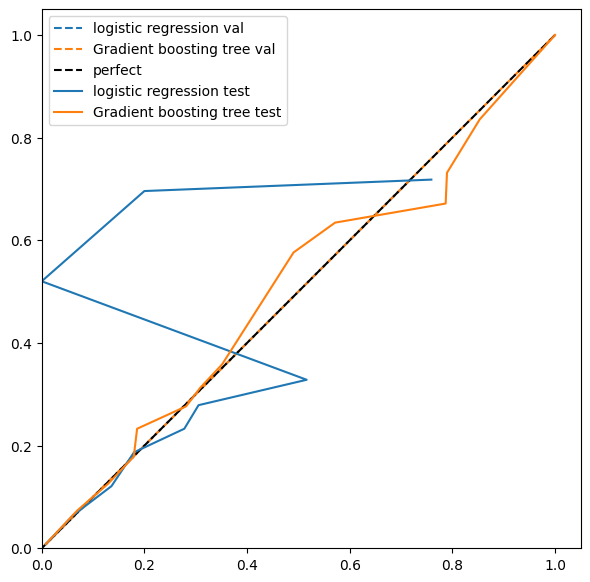

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

ax.plot(lr_prob_true_val_calibrated, lr_prob_pred_val_calibrated, label="logistic regression val", color="C0", linestyle="--")
ax.plot(gbt_prob_true_val_calibrated, gbt_prob_pred_val_calibrated, label="Gradient boosting tree val",color="C1", linestyle="--")

ax.plot([0, 1],[0, 1], color="k", linestyle="--", label="perfect")

ax.plot(lr_prob_true_test_calibrated, lr_prob_pred_test_calibrated, label="logistic regression test")
ax.plot(gbt_prob_true_test_calibrated, gbt_prob_pred_test_calibrated, label="Gradient boosting tree test")

ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1.05)
ax.set_aspect("equal", "box")
ax.legend()

Now we had a really good calibrated model

Next, we set a threshold of 0.05. Currently, only 5% of push notifications are opened. If we assume that when we send a push notification about a product a client is likely to be interested in, they will open it, we can proceed accordingly.

By establishing a threshold of 5% and only sending a notification when the predicted probability of a client purchasing the product exceeds this value, we expect to increase the proportion of push notifications that are opened by clients

Now, with a threshold of 0.05, a push notification is sent only if the predicted probability of opening exceeds this value. In this case, we convert the model into a binary one (0 and 1).

In [17]:
th = 0.05
gbt_test_binary_pred = (test_gbt_calibrated_pred > th).astype(int)
lr_test_binary_pred = (test_lr_calibrated_pred > th).astype(int)

In [18]:
def get_new_metrics(y_true, y_pred, name=""):
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
    results = pd.Series(
        {
            "precision": precision[1],
            "recall": recall[1],
            "f1": f1[1],
            "prevalence": support[1] / (support[0] + support[1]),
        },
        name=name,
    )
    return results

In [19]:
gbt_test_results = get_new_metrics(y_test, gbt_test_binary_pred, name="gbt")
lr_test_results = get_new_metrics(y_test, lr_test_binary_pred, name="lr")

test_results = pd.concat([gbt_test_results, lr_test_results], axis=1)

In [27]:
test_results

,gbt,lr
precision,0.159165,0.148267
recall,0.404481,0.407429
f1,0.228438,0.217415
prevalence,0.012874,0.012874


As expectet the GBT has a better precision an a better recall. We can see that th 16% of positives, are actually real positives and that we are able of detect the 40% of the positive push. That's not bad. 

## Interesting Checks:
We don't have enough time, but if we did, it would be interesting to look into the following:
* Does it work differently depending on the type of user? For example, does it perform better for older users than for new ones?
* How does it perform depending on the product? For example, comparing the least popular products with the most popular ones.

In [ ]:
train_users = X_train["user_id"].unique()
val_users = X_val["user_id"].unique()
test_users = X_test["user_id"].unique()

train_val_users = np.union1d(train_users, val_users) # we join users of training and validation
new_test_users = np.setdiff1d(test_users, train_val_users) # users in test and not in train neather in validation
old_test_users = np.intersect1d(test_users, train_val_users) # users in test and in train or validation

In [ ]:
# to detect which row corespons to a new or an old user
new_test_users_mask = X_test["user_id"].isin(new_test_users).values
old_test_users_mask = X_test["user_id"].isin(old_test_users).values

In [28]:
gbt_new_users_test_results = get_new_metrics(
    y_test[new_test_users_mask],
    gbt_test_binary_pred[new_test_users_mask],
    name="gbt"
)

lr_new_users_test_results = get_new_metrics(
    y_test[new_test_users_mask],
    lr_test_binary_pred[new_test_users_mask],
    name="lr"
)

test_new_users_results = pd.concat(
    [gbt_new_users_test_results, lr_new_users_test_results], axis=1
)

In [29]:
test_new_users_results

,gbt,lr
precision,0.167201,0.158596
recall,0.335280,0.340537
f1,0.223129,0.216407
prevalence,0.012004,0.012004


In [30]:
gbt_old_users_test_results = get_new_metrics(
    y_test[old_test_users_mask],
    gbt_test_binary_pred[old_test_users_mask],
    name="gbt"
)

lr_old_users_test_results = get_new_metrics(
    y_test[old_test_users_mask],
    lr_test_binary_pred[old_test_users_mask],
    name="lr"
)

test_old_users_results = pd.concat(
    [gbt_old_users_test_results, lr_old_users_test_results], axis=1
)

In [31]:
test_old_users_results

,gbt,lr
precision,0.153846,0.141541
recall,0.475000,0.475595
f1,0.232416,0.218157
prevalence,0.013901,0.013901


### Insights:
* We can observe that te precision is similar, maybe decreass a little bit.
* However, the recall is significantly worse for new users than for old ones.
* Something that is expectect. So works corrects.


## Final Conclusion
* The best model upen all the rest is the Gradient Boosting Tree. 
* To be specific, we saw that if we increas the nombers of trees works better. And the best model was GBT with 50 trees, debth of 5 and lr of 0.1.
* We made a time data splite. Bacause is a compania that is growing and changing alot during the time, so to avoid information leakage.
* Also we can see a very good calibration taking in count that is really good calibrated for prediccionts of a probability under 20% and ower threshold is 0.05, so is going to work really well detecting which push not to send. 